In [1]:
import os
import sys
word_dir = '/Users/lxx/Documents/codes/st-missing-fill'
os.chdir(word_dir)
sys.path.append(word_dir)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.data.misser import mask_mcar, mask_seq, mask_spatial

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

In [60]:
data = pd.read_parquet('data/processed/all_data.parquet')
data_cols = data.columns.tolist()
stations = sorted(pd.read_csv('data/processed/all_stations.csv', usecols=['Station'])['Station'].tolist())
vars = pd.read_csv('data/raw/geo_data/vars.csv', usecols=['name'])['name'].tolist()
vars = {'y': 'wind_speed', 'x': [var for var in vars if var != 'wind_speed']}

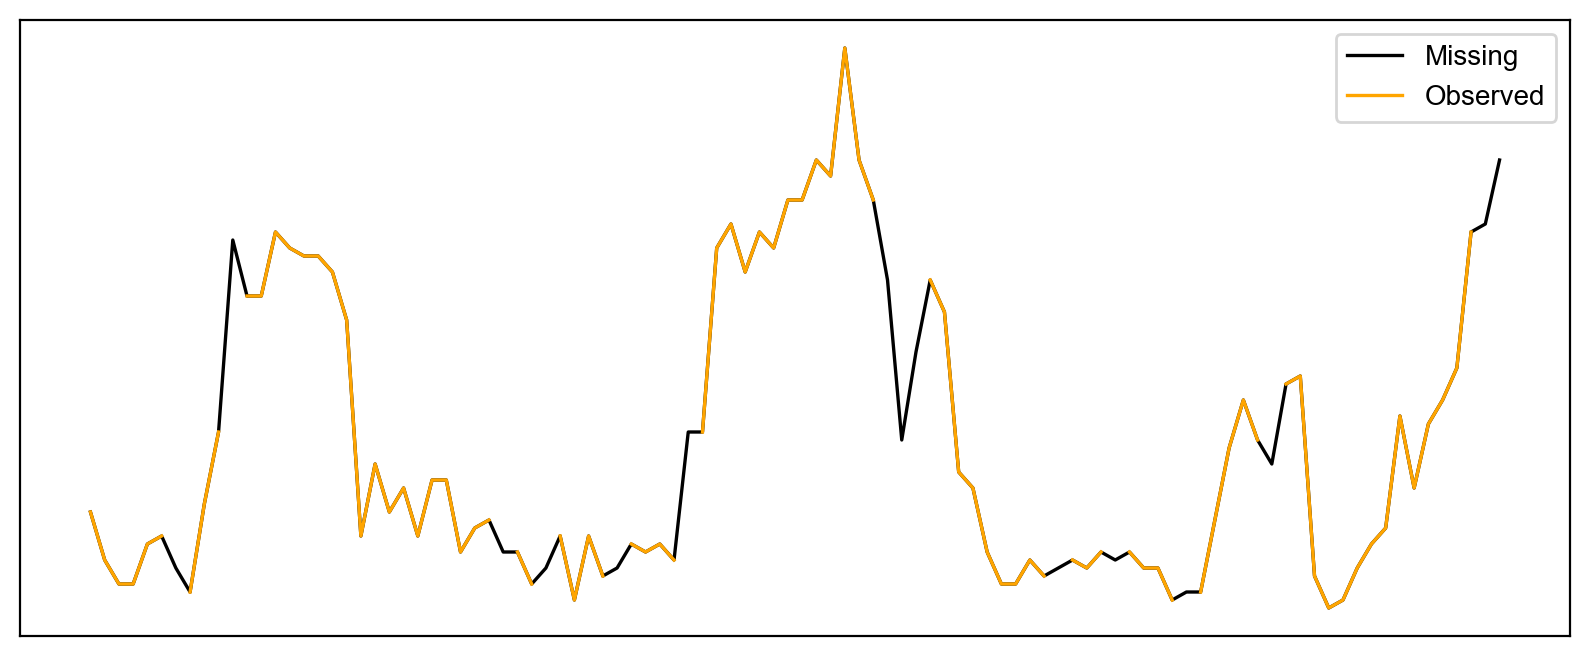

In [76]:
ground_y = data[[f'{s}~{vars["y"]}' for s in stations]].to_numpy().transpose()
mask = mask_mcar(size=ground_y.shape)

data1 = groud_y[0][:100]               # 原始数据
data1_masked = np.where(mask[0][:100] == 1, data1, np.nan)

# 绘图
plt.figure(figsize=(10, 4))
plt.plot(data1, color='black', label='Missing', linewidth=1.2)
plt.plot(data1_masked, color='orange', label='Observed', linewidth=1.2)

plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

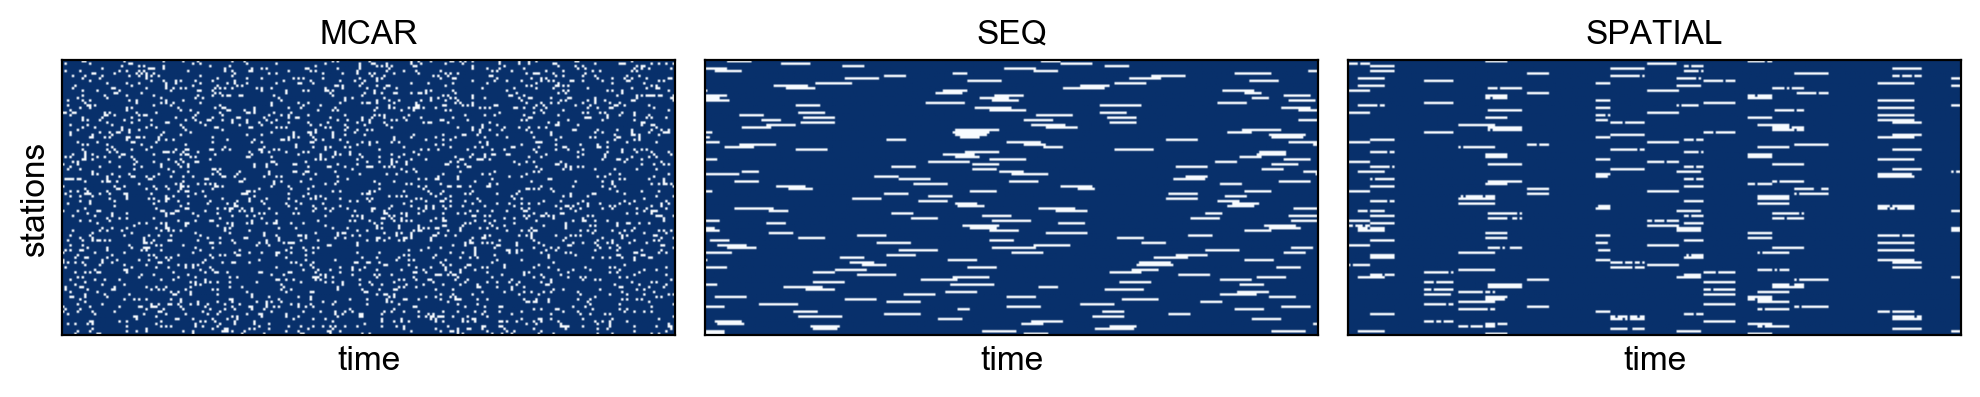

In [59]:
S_cluster = pd.read_csv('data/processed/all_stations.csv')['cluster'].tolist()

mask1 = mask_mcar() # mcar
mask2 = mask_seq() # seq
mask3 = mask_spatial(S_cluster=S_cluster) # spatial

plt.figure(figsize=(10, 6))
a, delta_a = 3800, 250
for i, maski in enumerate([mask1, mask2, mask3]):
    ax = plt.subplot(1, 3, i+1)
    im = ax.imshow(maski[:, a:a+delta_a], cmap='Blues')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{["MCAR", "SEQ", "SPATIAL"][i]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('time', fontsize=12)
    if i == 0:
        ax.set_ylabel('stations', fontsize=12)
plt.tight_layout()
plt.show()